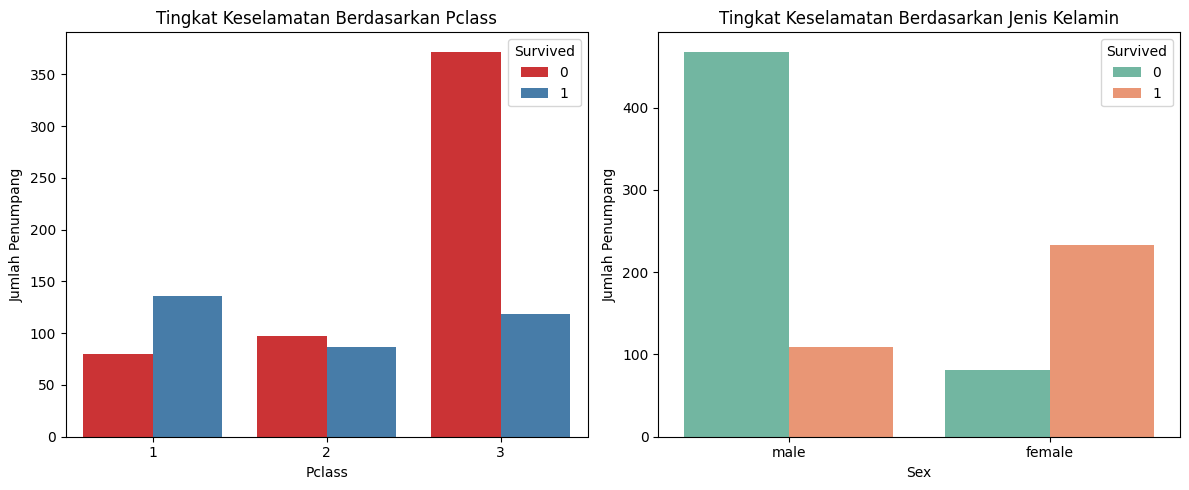

In [2]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed untuk reproducibility sesuai instruksi
import random
import os
import tensorflow as tf

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# Memuat dataset (pastikan file train.csv sudah diupload ke session Colab)
df = pd.read_csv('train.csv')

# --- EKSPLORASI DATA (EDA) ---
plt.figure(figsize=(12, 5))

# Grafik 1: Tingkat Keselamatan berdasarkan Kelas Penumpang (Pclass)
plt.subplot(1, 2, 1)
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set1')
plt.title('Tingkat Keselamatan Berdasarkan Pclass')
plt.ylabel('Jumlah Penumpang')

# Grafik 2: Tingkat Keselamatan berdasarkan Jenis Kelamin (Sex)
plt.subplot(1, 2, 2)
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Tingkat Keselamatan Berdasarkan Jenis Kelamin')
plt.ylabel('Jumlah Penumpang')

plt.tight_layout()
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

# Copy data agar data asli tidak berubah
data = df.copy()

# 1. Feature Engineering: Ekstraksi Title dari Nama
data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
# Menggabungkan title yang jarang muncul menjadi 'Rare'
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
data['Title'] = data['Title'].replace(rare_titles, 'Rare')
data['Title'] = data['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# 2. Feature Engineering: Menghitung Family Size
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

# 3. Imputasi Missing Values
# Imputasi Age menggunakan median dari masing-masing Title
data['Age'] = data.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
# Imputasi Embarked menggunakan modus
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
# Imputasi Fare menggunakan median (berjaga-jaga jika nanti data test memiliki missing Fare)
data['Fare'] = data['Fare'].fillna(data['Fare'].median())

# 4. Feature Engineering: Binning Usia
# Membagi usia menjadi 5 kelompok berukuran sama
data['AgeBin'] = pd.qcut(data['Age'], 5, labels=['Bayi/Anak', 'Remaja', 'Dewasa Muda', 'Dewasa', 'Lansia'])

# 5. Drop kolom yang tidak relevan atau sudah diekstrak
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Age']
data = data.drop(columns=columns_to_drop)

# 6. Encoding Kategorikal (One-Hot Encoding)
categorical_cols = ['Sex', 'Embarked', 'Title', 'AgeBin']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# 7. Memisahkan fitur (X) dan target (y)
X = data.drop('Survived', axis=1)
y = data['Survived']

# 8. Feature Scaling untuk variabel numerik yang tersisa
scaler = StandardScaler()
num_cols = ['Fare', 'SibSp', 'Parch', 'FamilySize']
X[num_cols] = scaler.fit_transform(X[num_cols])

print("Shape dataset setelah preprocessing:", X.shape)
X.head()

Shape dataset setelah preprocessing: (891, 16)


,Pclass,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeBin_Remaja,AgeBin_Dewasa Muda,AgeBin_Dewasa,AgeBin_Lansia
0,3,0.432793,-0.473674,-0.502445,0.059160,True,False,True,False,True,False,False,True,False,False,False
1,1,0.432793,-0.473674,0.786845,0.059160,False,False,False,False,False,True,False,False,False,True,False
2,3,-0.474545,-0.473674,-0.488854,-0.560975,False,False,True,True,False,False,False,True,False,False,False
3,1,0.432793,-0.473674,0.420730,0.059160,False,False,True,False,False,True,False,False,False,True,False
4,3,-0.474545,-0.473674,-0.486337,-0.560975,True,False,True,False,True,False,False,False,False,True,False


In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import time
import pandas as pd

# 1. Membagi data menjadi Train (80%) dan Test (20%)
# Ingat: Pembagian (X_train, X_test) ini yang akan kita pakai lagi untuk model Deep Learning
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}\n")


# 2. LOGISTIC REGRESSION (Baseline Linear)
print("--- Training Logistic Regression ---")
start_time_lr = time.time()

# Hyperparameter tuning dasar menggunakan GridSearch
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [500]
}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

time_lr = time.time() - start_time_lr
best_lr = grid_lr.best_estimator_

# Prediksi dan Evaluasi
y_pred_lr = best_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Parameter Terbaik LR: {grid_lr.best_params_}")
print(f"Waktu Training LR: {time_lr:.4f} detik")
print(f"Akurasi Test LR: {acc_lr:.4f}\n")

# 3. RANDOM FOREST (Baseline Tree-Based)
print("--- Training Random Forest ---")
start_time_rf = time.time()

# Hyperparameter tuning dasar
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

time_rf = time.time() - start_time_rf
best_rf = grid_rf.best_estimator_

# Prediksi dan Evaluasi
y_pred_rf = best_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Parameter Terbaik RF: {grid_rf.best_params_}")
print(f"Waktu Training RF: {time_rf:.4f} detik")
print(f"Akurasi Test RF: {acc_rf:.4f}\n")

# 4. RINGKASAN BASELINE
baseline_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Test Accuracy': [acc_lr, acc_rf],
    'Training Time (s)': [time_lr, time_rf]
})

print("--- RINGKASAN HASIL KONVENSIONAL ---")
display(baseline_results)

Jumlah data training: 712
Jumlah data testing: 179

--- Training Logistic Regression ---
Parameter Terbaik LR: {'C': 10, 'max_iter': 500}
Waktu Training LR: 2.1495 detik
Akurasi Test LR: 0.8492

--- Training Random Forest ---
Parameter Terbaik RF: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Waktu Training RF: 23.2248 detik
Akurasi Test RF: 0.8324

--- RINGKASAN HASIL KONVENSIONAL ---


,Model,Test Accuracy,Training Time (s)
0,Logistic Regression,0.849162,2.149545
1,Random Forest,0.832402,23.224810


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Set seed khusus untuk TensorFlow agar hasilnya reproducible
tf.random.set_seed(42)

print("--- Training Deep Learning (MLP) ---")
start_time_mlp = time.time()

# 1. Membangun Arsitektur MLP
model = Sequential([
    # Input layer & Hidden Layer 1
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3), # Regularisasi: mematikan 30% neuron secara acak

    # Hidden Layer 2
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3), # Regularisasi

    # Output Layer (Binary Classification: Survived 0 atau 1)
    Dense(1, activation='sigmoid')
])

# 2. Kompilasi Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 3. Menyiapkan Early Stopping (Regularisasi tambahan)
# Memantau val_loss, berhenti jika tidak membaik dalam 10 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 4. Training Model
# Menggunakan 20% dari data train sebagai validation set selama proses training
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=1) # verbose=1 agar Anda bisa melihat proses per epoch

time_mlp = time.time() - start_time_mlp

# 5. Evaluasi pada Test Set (Data yang belum pernah dilihat model)
loss_mlp, acc_mlp = model.evaluate(X_test, y_test, verbose=0)

# Menghitung jumlah parameter
total_params = model.count_params()

print("\n--- HASIL DEEP LEARNING ---")
print(f"Waktu Training MLP: {time_mlp:.4f} detik")
print(f"Akurasi Test MLP: {acc_mlp:.4f}")
print(f"Total Parameter: {total_params}")

--- Training Deep Learning (MLP) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5923 - loss: 0.8138 - val_accuracy: 0.6993 - val_loss: 0.6143
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6837 - loss: 0.6548 - val_accuracy: 0.7063 - val_loss: 0.5850
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7311 - loss: 0.5804 - val_accuracy: 0.7133 - val_loss: 0.5641
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7627 - loss: 0.5232 - val_accuracy: 0.7273 - val_loss: 0.5467
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7821 - loss: 0.4991 - val_accuracy: 0.7413 - val_loss: 0.5290
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7750 - loss: 0.5089 - val_accuracy: 0.7343 - val_loss: 0.5167
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7698 - loss: 0.4879 - val_accuracy: 0.7552 - val_loss: 0.5095
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7838 - loss: 0.4831 - val_accuracy: 0.7483 - 

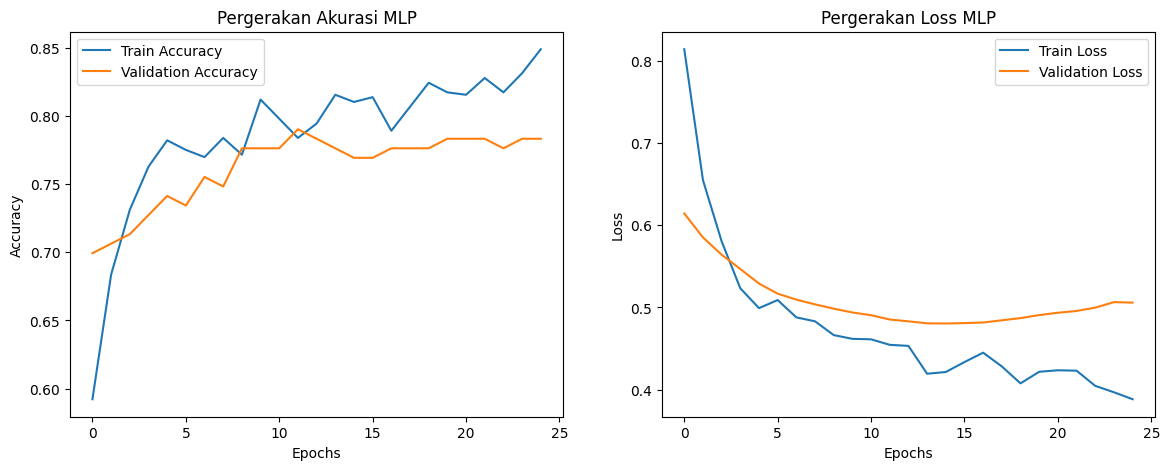

In [6]:
# Visualisasi Akurasi dan Loss
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Akurasi
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_title('Pergerakan Akurasi MLP')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Plot Loss
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Validation Loss')
ax[1].set_title('Pergerakan Loss MLP')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.show()

In [9]:
import numpy as np

# 1. Mendapatkan Prediksi dari Model MLP
# Output MLP adalah probabilitas (karena fungsi aktivasi sigmoid), jadi kita ubah ke 0 atau 1
y_pred_mlp_prob = model.predict(X_test)
y_pred_mlp = (y_pred_mlp_prob > 0.5).astype(int).flatten()

# 2. Membuat Tabel Perbandingan Lengkap
final_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'MLP (Deep Learning)'],
    'Test Accuracy': [acc_lr, acc_rf, acc_mlp],
    'Training Time (s)': [time_lr, time_rf, time_mlp],
    'Total Parameters': [len(best_lr.coef_[0]) + 1, 'N/A (Tree-based)', total_params]
})

print("--- TABEL PERBANDINGAN KASUS 1 (TITANIC) ---")
display(final_results)

# 3. Analisis Error: Mencari Penumpang yang Salah Diprediksi oleh MLP
# Cari index data test di mana Aktual != Prediksi
errors_idx = y_test[y_test != y_pred_mlp].index

# Mengambil data ASLI (sebelum preprocessing) berdasarkan index error tersebut
error_samples = df.loc[errors_idx].copy()

# Menambahkan kolom tebakan vs kenyataan agar mudah dianalisis
# Perlu mencari posisi index yang sesuai di array y_pred_mlp
mask = np.isin(y_test.index, errors_idx)
error_samples['Actual_Survived'] = y_test.loc[errors_idx].values
error_samples['Predicted_Survived'] = y_pred_mlp[mask]

print("\n--- CONTOH ANALISIS ERROR (SALAH PREDIKSI OLEH MLP) ---")
print("Catatan: Actual=1 (Selamat), Actual=0 (Tidak Selamat)")
# Menampilkan 5 contoh kesalahan teratas dengan fitur-fitur penting
display(error_samples[['Name', 'Pclass', 'Sex', 'Age', 'Fare', 'Actual_Survived', 'Predicted_Survived']].head(5))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
--- TABEL PERBANDINGAN KASUS 1 (TITANIC) ---


,Model,Test Accuracy,Training Time (s),Total Parameters
0,Logistic Regression,0.849162,2.149545,17
1,Random Forest,0.832402,23.224810,N/A (Tree-based)
2,MLP (Deep Learning),0.793296,6.710258,3585



--- CONTOH ANALISIS ERROR (SALAH PREDIKSI OLEH MLP) ---
Catatan: Actual=1 (Selamat), Actual=0 (Tidak Selamat)


,Name,Pclass,Sex,Age,Fare,Actual_Survived,Predicted_Survived
553,"Leeni, Mr. Fahim (""Philip Zenni"")",3,male,22.0,7.225,1,0
559,"de Messemaeker, Mrs. Guillaume Joseph (Emma)",3,female,36.0,17.400,1,0
536,"Butt, Major. Archibald Willingham",1,male,45.0,26.550,0,1
216,"Honkanen, Miss. Eliina",3,female,27.0,7.925,1,0
712,"Taylor, Mr. Elmer Zebley",1,male,48.0,52.000,1,0
